In [1]:
from typing import TypedDict, List, Optional
from langgraph.graph import StateGraph

In [2]:
class AgentState(TypedDict):
    name: str
    age: int
    skill: List[str]
    result: Optional[str]

In [3]:
graph = StateGraph(AgentState)

In [4]:
def firstNode(state:AgentState) -> AgentState:
    """Personalizes the name with a greeting"""
    state["result"] = f"{state['name']},welcome to the system!"
    return state

def secondNode(state:AgentState) -> AgentState:
    """Describes the users age"""
    state["result"] = f"{state['result']},Your are {state['age']} years old!"
    return state

def thirdNode(state:AgentState) -> AgentState:
    """list user skills"""
    state["result"] = state["result"] + f"You have skills in {','.join(state['skill'])}"
    return state


In [5]:
graph.add_node("first", firstNode)
graph.add_node("second", secondNode)
graph.add_node("third", thirdNode)
graph.add_edge("first", "second")
graph.add_edge("second", "third")
graph.set_entry_point("first")
graph.set_finish_point("third")
app = graph.compile()

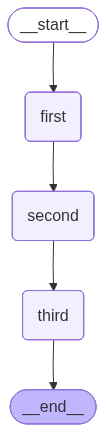

In [6]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))


In [7]:
result = app.invoke({"name": "zlpei", "age": 23, "skill": ["js", "ts", "python"],"result":""})

print(result)

{'name': 'zlpei', 'age': 23, 'skill': ['js', 'ts', 'python'], 'result': 'zlpei,welcome to the system!,Your are 23 years old!You have skills in js,ts,python'}
